# 10 - Dashboard + 最终报告

汇总整个项目的关键结果，生成最终输出文件。

**最终交付物**：
1. `safety_sft_mix.jsonl` — SFT 训练数据
2. `safety_dpo_pairs.jsonl` — DPO 训练对
3. `safety_eval.jsonl` — 评估数据集
4. `dataset_card.md` — 数据集卡片

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

from src.utils.config_loader import print_config, load_run_config, get_data_path, get_results_path

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')

print_config()

  当前运行模式: SMOKE_TEST
  文本样本数:     2,000
  图文样本数:     500
  合成增强数:     50
  分类器 Epochs:  1
  设备:           mps
  随机种子:       42


## 1. 数据流水线总览

In [2]:
# 统计各阶段数据量
stages = {}

# 原始数据
raw_path = get_data_path('unified') / 'text_safety.jsonl'
if raw_path.exists():
    stages['1. Raw (Unified)'] = sum(1 for _ in open(raw_path))

# 清洗后
cleaned_path = get_data_path('cleaned') / 'text_safety_cleaned.jsonl'
if cleaned_path.exists():
    stages['2. Cleaned'] = sum(1 for _ in open(cleaned_path))

# 增强数据
aug_path = get_data_path('augmented') / 'augmented_data.jsonl'
if aug_path.exists():
    stages['3. Augmented'] = sum(1 for _ in open(aug_path))

# 合计
stages['4. Total (Cleaned + Aug)'] = stages.get('2. Cleaned', 0) + stages.get('3. Augmented', 0)

print('数据流水线各阶段统计:')
for stage, count in stages.items():
    print(f'  {stage}: {count:,}')

数据流水线各阶段统计:
  1. Raw (Unified): 9,480
  2. Cleaned: 6,529
  3. Augmented: 243
  4. Total (Cleaned + Aug): 6,772


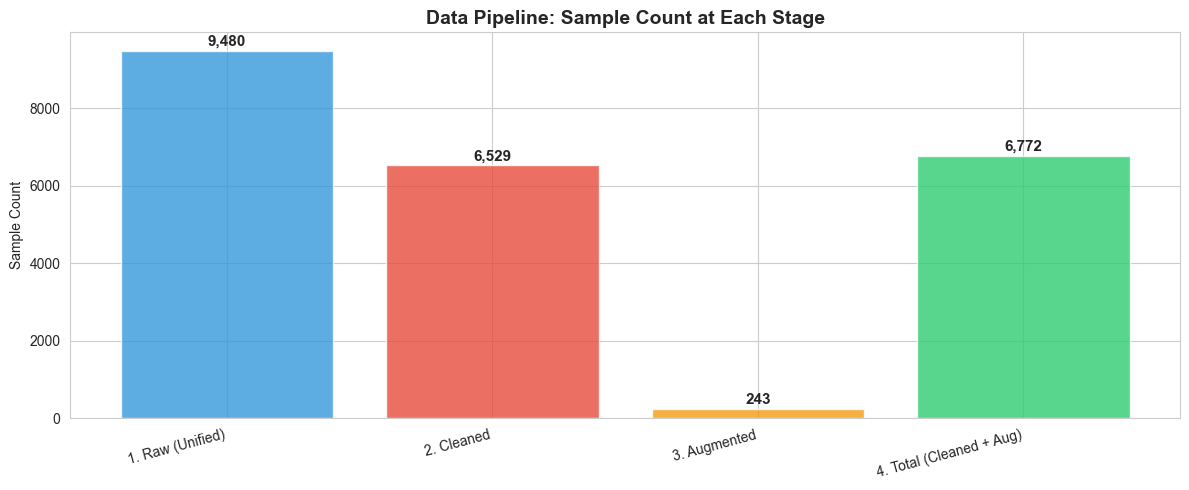

In [3]:
# 可视化数据流
fig, ax = plt.subplots(figsize=(12, 5))
stage_names = list(stages.keys())
stage_counts = list(stages.values())

colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
bars = ax.bar(range(len(stage_names)), stage_counts, color=colors[:len(stage_names)], alpha=0.8)
ax.set_xticks(range(len(stage_names)))
ax.set_xticklabels(stage_names, rotation=15, ha='right')
ax.set_title('Data Pipeline: Sample Count at Each Stage', fontsize=14, fontweight='bold')
ax.set_ylabel('Sample Count')
for bar, count in zip(bars, stage_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/data_pipeline_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. 生成最终输出文件

In [4]:
from scripts.generate_report import generate_sft_mix, generate_dpo_pairs, generate_eval_data, generate_dataset_card

sft_data = generate_sft_mix()
dpo_pairs = generate_dpo_pairs()
eval_data = generate_eval_data()
card = generate_dataset_card()

SFT 混合数据: 6,772 条 → /Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/safety-dataset/data/final/safety_sft_mix.jsonl


DPO 训练对: 4,225 条 → /Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/safety-dataset/data/final/safety_dpo_pairs.jsonl
评估数据: 1,305 条 → /Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/safety-dataset/data/final/safety_eval.jsonl
数据集卡片: /Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/safety-dataset/data/final/dataset_card.md


## 3. 最终数据集统计

In [5]:
# 加载最终数据统计
final_dir = get_data_path('final')

# SFT 数据分析
sft_cats = Counter(r.get('meta', {}).get('risk_category', 'unknown') for r in sft_data)
sft_labels = Counter(r.get('meta', {}).get('prompt_harm_label', 'unknown') for r in sft_data)
sft_sources = Counter(r.get('meta', {}).get('source', 'unknown') for r in sft_data)

print('SFT 混合数据统计:')
print(f'  总量: {len(sft_data):,}')
print(f'  标签分布: {dict(sft_labels)}')
print(f'  来源数: {len(sft_sources)}')
print(f'  类别数: {len(sft_cats)}')

print(f'\nDPO 训练对: {len(dpo_pairs):,}')
print(f'评估数据: {len(eval_data):,}')

SFT 混合数据统计:
  总量: 6,772
  标签分布: {'harmful': 4225, 'unharmful': 2547}
  来源数: 14
  类别数: 16

DPO 训练对: 4,225
评估数据: 1,305


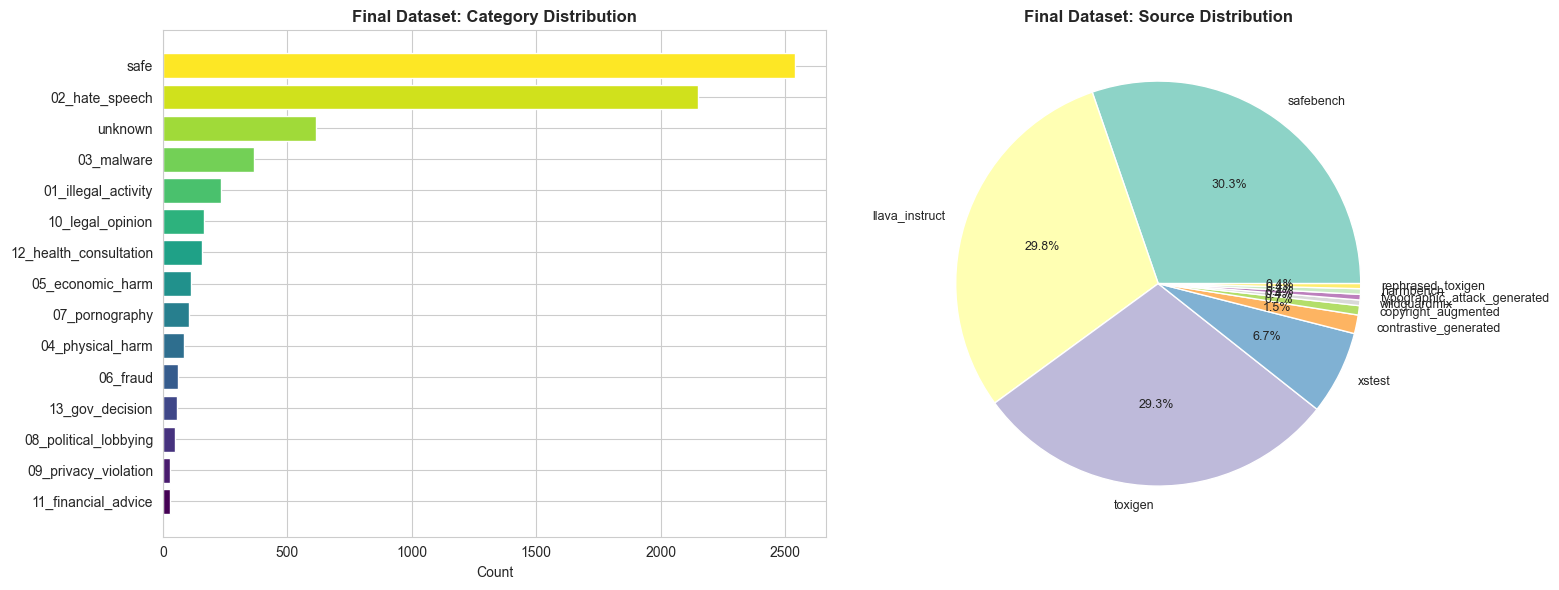

In [6]:
# 最终数据集类别分布
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 类别分布
top_cats = sft_cats.most_common(15)
cat_names = [c for c, _ in top_cats]
cat_counts = [c for _, c in top_cats]
axes[0].barh(cat_names[::-1], cat_counts[::-1], color=plt.cm.viridis(np.linspace(0, 1, len(cat_names))))
axes[0].set_title('Final Dataset: Category Distribution', fontweight='bold')
axes[0].set_xlabel('Count')

# 来源分布
top_sources = sft_sources.most_common(10)
src_names = [s for s, _ in top_sources]
src_counts = [c for _, c in top_sources]
axes[1].pie(src_counts, labels=src_names, autopct='%1.1f%%',
            colors=plt.cm.Set3(np.linspace(0, 1, len(src_names))), textprops={'fontsize': 9})
axes[1].set_title('Final Dataset: Source Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/final_dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 模型性能 Dashboard

In [7]:
# 加载训练结果
training_path = get_results_path('training') / 'training_summary.json'
ablation_path = get_results_path('ablation') / 'ablation_results.json'

model_metrics = {}
if training_path.exists():
    with open(training_path) as f:
        training_data = json.load(f)
    for model_name, data in training_data.items():
        if 'metrics' in data:
            model_metrics[model_name] = data['metrics']

ablation_data = {}
if ablation_path.exists():
    with open(ablation_path) as f:
        ablation_data = json.load(f)

# Dashboard 表格
print('=' * 60)
print('  模型性能 Dashboard')
print('=' * 60)

for name, m in model_metrics.items():
    print(f'\n{name}:')
    for k, v in m.items():
        if isinstance(v, float):
            print(f'  {k:20s}: {v:.4f}')

  模型性能 Dashboard


In [8]:
# Dashboard 可视化
if model_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 模型对比
    model_names = list(model_metrics.keys())
    metric_names = ['auc', 'f1', 'recall', 'precision']
    x = range(len(metric_names))
    width = 0.35

    for i, model_name in enumerate(model_names[:2]):
        m = model_metrics[model_name]
        vals = [m.get(mn, 0) for mn in metric_names]
        offset = (i - 0.5) * width
        bars = axes[0].bar([xi + offset for xi in x], vals, width, label=model_name, alpha=0.8)

    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels([m.upper() for m in metric_names])
    axes[0].set_title('Model Performance Dashboard', fontweight='bold')
    axes[0].set_ylim(0, 1.1)
    axes[0].legend()

    # 项目总结
    summary_text = (
        f'Project Summary\n'
        f'==============\n'
        f'Raw Data: {stages.get("1. Raw (Unified)", 0):,}\n'
        f'Cleaned: {stages.get("2. Cleaned", 0):,}\n'
        f'Augmented: {stages.get("3. Augmented", 0):,}\n'
        f'Final SFT: {len(sft_data):,}\n'
        f'Final DPO: {len(dpo_pairs):,}\n'
        f'Final Eval: {len(eval_data):,}\n'
        f'Risk Categories: 14\n'
        f'Data Sources: {len(sft_sources)}\n'
    )
    axes[1].text(0.1, 0.5, summary_text, transform=axes[1].transAxes,
                fontsize=13, verticalalignment='center', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    axes[1].axis('off')
    axes[1].set_title('Project Statistics', fontweight='bold')

    plt.tight_layout()
    plt.savefig('../results/figures/dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. 项目回顾与关键贡献

### 完成的工作
1. **数据采集**：8 个公开数据集 + 统一格式转换
2. **数据清洗**：Data-Juicer 风格 Pipeline，安全数据专用宽松阈值
3. **OCR + CLIP 双层防护**：OCR 做廉价初筛，CLIP 做语义级检测
4. **数据增强**：对比样本 + 类别平衡 + 印刷术攻击 + 版权数据
5. **模型训练**：DistilBERT 文本分类 + CLIP 多模态分类
6. **Benchmark 评估**：4 个标准测试集
7. **消融实验**：6 组实验量化各组件贡献

### 关键创新点
- **14 类风险分类**：增加了版权类别（TikTok 特需）
- **对比数据构造**：解决 over-refusal 问题
- **OCR + 多模态级联**：工业级成本效率
- **完整消融验证**：每个组件的贡献都可量化

### 生产部署建议
```
Layer 1: DistilBERT (~10ms, ~66M params)  -> 过滤 90% 内容
Layer 2: CLIP Head  (~100ms)               -> 图文攻击检测
Layer 3: 7B/13B LLM (~1s)                  -> 困难样本
Layer 4: 人工审核                            -> 最终仲裁
```

In [9]:
# 保存最终结果
results_summary = {
    'data_pipeline': stages,
    'final_datasets': {
        'sft_mix': len(sft_data),
        'dpo_pairs': len(dpo_pairs),
        'eval_set': len(eval_data),
    },
    'model_metrics': {k: {kk: vv for kk, vv in v.items() if isinstance(vv, (int, float))} for k, v in model_metrics.items()},
}

save_path = get_results_path('') / 'final_summary.json'
with open(save_path, 'w') as f:
    json.dump(results_summary, f, indent=2, ensure_ascii=False)
print(f'最终结果保存到: {save_path}')

print('\n' + '=' * 60)
print('  项目完成！')
print('=' * 60)

最终结果保存到: /Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/safety-dataset/results/final_summary.json

  项目完成！
